# Tarea 3 — Parte 3  
## Aproximación multiescala a SMV para remoción de campo de fondo en QSM

Este notebook desarrolla la **Parte 3** del enunciado, abordando de manera explícita los siguientes puntos:

- **3.1)** Aproximación multiescala del filtrado SMV usando la fase local.
- **3.2)** Deconvolución del operador equivalente.
- **3.3)** Aplicación a la fase total.
- **3.4)** Discusión de bordes y propuesta de solución.
- **3.5)** Uso de la MMT en la aproximación del operador SMV.

En QSM, el campo de fondo satisface aproximadamente la ecuación de Laplace dentro de la ROI:

$$
\nabla^2 B \approx 0,
$$

lo que implica que corresponde a una componente suave (armónica) del campo. Métodos como SMV/SHARP buscan remover esta componente mediante operadores de suavizado espacial.

En este contexto, se utiliza la descomposición Starlet 3D para construir una aproximación multiescala del operador pasaaltos:

$$
g_J = b - c_J,
$$

donde:

- $b$ es el volumen de entrada;
- $c_J$ es el residual suave de la descomposición Starlet;
- $g_J$ representa las componentes de alta frecuencia (variaciones locales).

En el marco de SMV/SHARP, el operador ideal puede expresarse como $(I - S_r)b$, donde $S_r$ corresponde a un promedio esférico. En este notebook no se implementa un filtro SMV exacto, sino una aproximación basada en la separación multiescala inducida por la transformada Starlet.

## Datos utilizados

El enunciado usa la notación:

- `bloc`: fase local;
- `btot`: fase total.

En este notebook se usa el siguiente mapeo directo:

| Concepto del enunciado | Archivo usado | Variable |
|---|---|---|
| `btot` | `unwrapped_seguetotalphase.nii` | `total_phase` |
| `bloc` | `unwrapped_truelocalphase.nii` | `local_phase` |
| local estimada | `local_vsharp_m4.nii` | `vsharp_local` |
| máscara | `mask4.nii` | `mask` |

La fase local verdadera se usa como referencia principal en 3.1 y 3.2.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nibabel as nib
from scipy.ndimage import convolve, laplace, binary_erosion, median_filter
from scipy.stats import pearsonr
from numpy.fft import fftn, ifftn

# Ajuste de rutas para ejecutar el notebook desde la raíz del repositorio
# o desde notebooks/task3 sin modificar imports ni paths
ROOT = Path.cwd()
if ROOT.name == "task3":
    ROOT = ROOT.parents[1]
elif ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC = ROOT / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.append(str(SRC))

DATA_DIR = ROOT / "data" / "raw" / "task1"
RESULTS_DIR = ROOT / "results" / "task3" / "part3_t1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

ROOT: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs
DATA_DIR: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/data/raw/task1
RESULTS_DIR: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/results/task3/part3_t1


In [2]:
# Función auxiliar para guardar figuras con nombres consistentes para el informe
def save_current_fig(filename, dpi=200):
    path = RESULTS_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    #print("Saved:", path)

# 0. Carga de datos y utilidades comunes

Esta sección define los elementos reutilizados en las secciones 3.1–3.5:

1. carga de volúmenes NIfTI;
2. aplicación de la máscara ROI;
3. funciones de visualización;
4. cálculo de métricas dentro de la máscara.

Las métricas se evalúan únicamente dentro de la máscara, ya que en imágenes QSM/MRI el fondo externo puede contener valores nulos o no informativos que distorsionan la estimación de errores y correlaciones.

## 0.1 Carga de volúmenes

Esta celda carga los archivos `.nii` asociados a la fase RM/QSM:

- `true_local`: fase local verdadera (`unwrapped_truelocalphase.nii`);
- `total_phase`: fase total (`unwrapped_seguetotalphase.nii`);
- `vsharp_local`: fase local estimada con V-SHARP (`local_vsharp_m4.nii`);
- `mask`: máscara ROI (`mask4.nii`).

La aplicación de la máscara (multiplicación por `mask`) restringe el análisis a la región de interés, eliminando la contribución de voxeles externos que no contienen información relevante.

In [3]:
def load_nifti(path):
    img = nib.load(str(path))
    return img.get_fdata(dtype=np.float64)

# Volúmenes usados en la Parte 3: fase total, fase local verdadera
# y estimación local mediante V-SHARP para comparación
files = {
    "total_phase": "unwrapped_seguetotalphase.nii",
    "local_reference": "unwrapped_truelocalphase.nii",
    "vsharp_local": "local_vsharp_m4.nii",
}

mask_full = load_nifti(DATA_DIR / "mask4.nii") > 0
volumes_loaded_full = {name: load_nifti(DATA_DIR / fname) for name, fname in files.items()}

mask = mask_full
volumes_loaded = volumes_loaded_full

# Se aplica la máscara para restringir el análisis al dominio válido
local_phase = volumes_loaded["local_reference"] * mask
total_phase = volumes_loaded["total_phase"] * mask
vsharp_local = volumes_loaded["vsharp_local"] * mask

comparison_volumes = {
    "total_phase": total_phase,
    "local_reference": local_phase,
    "vsharp_local": vsharp_local,
}

assert all(v.shape == local_phase.shape for v in comparison_volumes.values())
assert mask.shape == local_phase.shape

print("full shape:", volumes_loaded_full["local_reference"].shape, "used shape:", local_phase.shape)
print("mask voxels:", int(mask.sum()))
for name, vol in volumes_loaded.items():
    print(f"{name:16s}", vol.shape, "min:", np.nanmin(vol), "max:", np.nanmax(vol))

full shape: (164, 205, 205) used shape: (164, 205, 205)
mask voxels: 1332273
total_phase      (164, 205, 205) min: -83.77690134051623 max: 85.64779938068881
local_reference  (164, 205, 205) min: -4.217599391937256 max: 4.492675304412842
vsharp_local     (164, 205, 205) min: -3.4999027252197266 max: 3.422898054122925


## 0.2 Funciones de visualización y métricas

Esta celda define funciones auxiliares:

- `show_slices`: muestra cortes 2D de volúmenes 3D;
- `masked_rmse`: error cuadrático medio dentro de la máscara;
- `relative_rmse`: RMSE normalizado por la energía de la referencia;
- `masked_corr`: correlación dentro de la máscara;
- `masked_energy`: energía media del volumen dentro de la máscara.

Estas métricas permiten evaluar diferencias entre volúmenes y analizar el comportamiento de las distintas componentes multiescala dentro de la región de interés.

In [4]:
# Límites robustos para visualización, evitando que valores extremos
# dominen el contraste de los cortes mostrados
def robust_limits(x, mask=None, q=(1, 99)):
    vals = np.asarray(x)[mask > 0] if mask is not None else np.asarray(x).ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 0, 1
    return np.percentile(vals, q)

def get_slice(vol, axis=2, index=None):
    if index is None:
        index = vol.shape[axis] // 2
    if axis == 0:
        return vol[index, :, :]
    if axis == 1:
        return vol[:, index, :]
    if axis == 2:
        return vol[:, :, index]
    raise ValueError("axis must be 0, 1 or 2")

def show_slices(vols, titles, axis=2, index=None, cmap="gray", mask_for_limits=None, figsize=(16,4)):
    fig, axes = plt.subplots(1, len(vols), figsize=figsize)
    if len(vols) == 1:
        axes = [axes]
    for ax, vol, title in zip(axes, vols, titles):
        sl = get_slice(vol, axis, index)
        if mask_for_limits is not None:
            msl = get_slice(mask_for_limits, axis, index)
            vmin, vmax = robust_limits(sl, msl)
        else:
            vmin, vmax = robust_limits(sl)
        im = ax.imshow(sl.T, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    return fig

# Las métricas se calculan únicamente dentro de la máscara para evitar
# que voxeles fuera del dominio válido afecten la comparación
def masked_rmse(a, b, m):
    d = (np.asarray(a) - np.asarray(b))[m > 0]
    return float(np.sqrt(np.mean(d**2)))

def relative_rmse(a, b, m):
    ref = np.asarray(a)[m > 0]
    d = (np.asarray(a) - np.asarray(b))[m > 0]
    return float(np.sqrt(np.mean(d**2)) / (np.sqrt(np.mean(ref**2)) + 1e-12))

# Correlación restringida a la máscara; si alguna región no tiene
# variabilidad suficiente, se devuelve NaN
def masked_corr(a, b, m):
    x = np.asarray(a)[m > 0].ravel()
    y = np.asarray(b)[m > 0].ravel()
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return np.nan
    return float(pearsonr(x[ok], y[ok])[0])

def masked_energy(x, m):
    vals = np.asarray(x)[m > 0]
    return float(np.mean(vals**2))

axis = 2
slice_idx = local_phase.shape[axis] // 2

## 0.3 Visualización inicial de los volúmenes principales

Esta celda muestra los volúmenes de fase utilizados en el análisis:

- `true_local` (`bloc`): fase local verdadera;
- `total_phase` (`btot`): fase total;
- `vsharp_local`: fase local estimada mediante V-SHARP;
- `mask`: máscara ROI.

## Interpretación

Se observa que la fase total presenta una componente suave de gran escala superpuesta a la estructura anatómica, característica del campo de fondo. En contraste, la fase local verdadera elimina esta componente, dejando principalmente variaciones locales de alta frecuencia asociadas a la anatomía.

La estimación V-SHARP reproduce en gran medida la estructura de la fase local, aunque pueden apreciarse pequeñas diferencias en algunas regiones, lo que sugiere una eliminación no completamente perfecta del fondo.

La máscara define correctamente la región de interés, cubriendo el volumen anatómico y excluyendo el fondo externo.

Esta visualización inicial proporciona una referencia clave para el resto del análisis, ya que permite anticipar que las diferencias entre `total_phase` y `true_local` estarán dominadas por componentes de baja frecuencia, mientras que las diferencias entre `vsharp_local` y `true_local` serán más sutiles y localizadas.

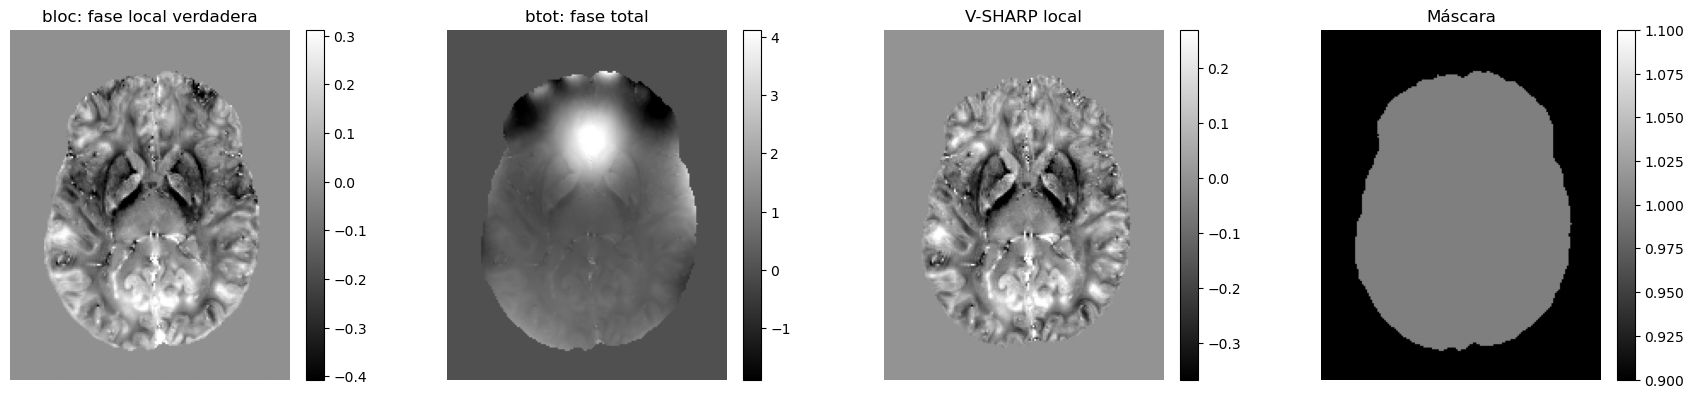

In [5]:
# Visualización inicial de los volúmenes de fase utilizados en el análisis
# (fase local verdadera, fase total, estimación V-SHARP y máscara)
fig = show_slices(
    [local_phase, total_phase, vsharp_local, mask.astype(float)],
    ["bloc: fase local verdadera", "btot: fase total", "V-SHARP local", "Máscara"],
    axis=axis,
    index=slice_idx,
    mask_for_limits=mask,
    figsize=(18,4),
)

# Guarda la figura para su inclusión en el informe
fig.savefig(RESULTS_DIR / f"part30_qsm_3-volumenes_principales.png", dpi=200, bbox_inches="tight")
plt.show()

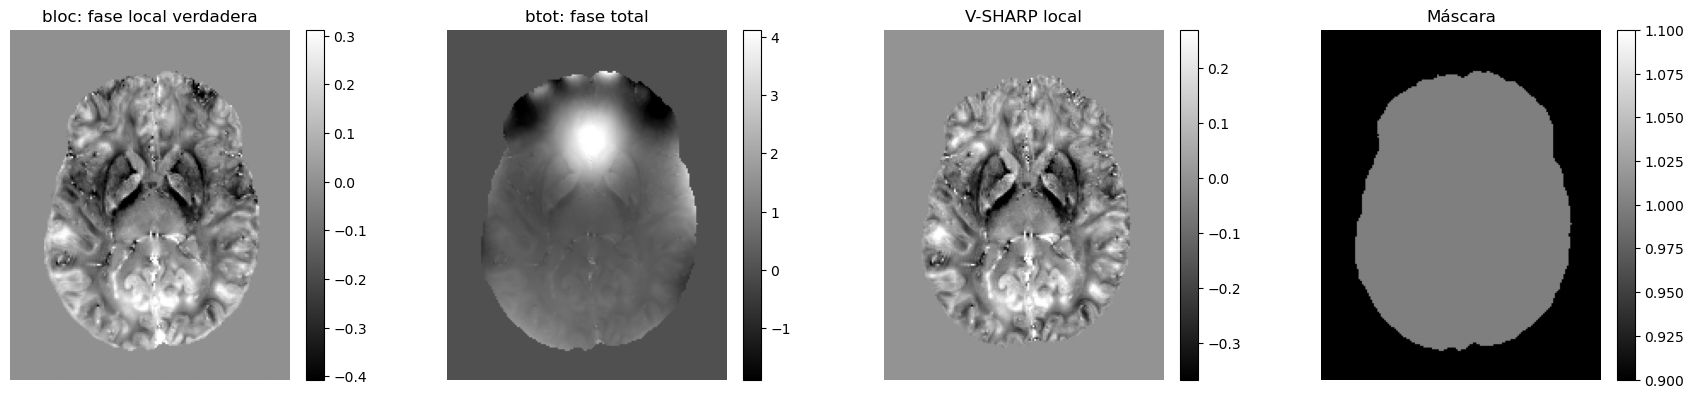

In [6]:
# Visualización inicial de los volúmenes de fase utilizados en el análisis
# (fase local verdadera, fase total, estimación V-SHARP y máscara)
fig = show_slices(
    [local_phase, total_phase, vsharp_local, mask.astype(float)],
    ["bloc: fase local verdadera", "btot: fase total", "V-SHARP local", "Máscara"],
    axis=axis,
    index=slice_idx,
    mask_for_limits=mask,
    figsize=(18,4),
)

# Guarda la figura para su inclusión en el informe
fig.savefig(RESULTS_DIR / f"part30_qsm_3-volumenes_principales.png", dpi=200, bbox_inches="tight")
plt.show()

# 0.1 Starlet 3D

Esta sección define o importa la transformada Starlet 3D.

La descomposición multiescala permite expresar el volumen como:

$$
b = c_J + \sum_{j=1}^{J} w_j,
$$

donde:

- $w_j$ son los detalles multiescala;
- $c_J$ es el residual suave;
- $g_J = b - c_J$ corresponde a la componente pasaaltos, equivalente a la suma de detalles.

La función `starlet_highpass` encapsula esta operación y se utilizará en las secciones 3.1, 3.2 y 3.3.

In [7]:
# Se intenta usar la implementación compartida del repositorio.
# Si no está disponible, se define una versión local equivalente
# para que el notebook sea ejecutable de forma autónoma
try:
    from course_utils.starlet3d import starlet_transform_3d, starlet_reconstruct_3d
    print("Usando src/course_utils/starlet3d.py")
except Exception as e:
    print("Usando implementación local:", repr(e))

    def kernel_1d(kind="b3spline"):
        if kind.lower() in {"b3", "b3spline", "b3-spline"}:
            return np.array([1,4,6,4,1], dtype=float) / 16.0
        if kind.lower() in {"binomial3", "binom3"}:
            return np.array([1,2,1], dtype=float) / 4.0
        raise ValueError("kernel inválido")

    # Kernel à trous 3D: se dilata el filtro insertando ceros entre
    # coeficientes para aumentar la escala sin submuestreo
    def atrous_kernel_3d(kind="b3spline", level=0):
        h = kernel_1d(kind)
        k = h[:,None,None] * h[None,:,None] * h[None,None,:]
        if level == 0:
            return k
        step = 2 ** level
        size = k.shape[0]
        new_size = size + (size - 1) * (step - 1)
        out = np.zeros((new_size, new_size, new_size))
        for i in range(size):
            for j in range(size):
                for z in range(size):
                    out[i*step, j*step, z*step] = k[i,j,z]
        return out

    def starlet_transform_3d(volume, n_scales=5, kernel="b3spline", mode="mirror"):
        c = np.asarray(volume, dtype=float).copy()
        details = []
        approximations = [c.copy()]
        for level in range(n_scales):
            cn = convolve(c, atrous_kernel_3d(kernel, level), mode=mode)
            details.append(c - cn)
            c = cn
            approximations.append(c.copy())
        return details, c, approximations

    def starlet_reconstruct_3d(details, cJ):
        rec = np.asarray(cJ, dtype=float).copy()
        for w in details:
            rec += w
        return rec

# El residual cJ actúa como componente pasa-bajos y gJ = volume - cJ
# define la componente pasaaltos multiescala usada como aproximación tipo SMV
def starlet_highpass(volume, J, kernel="b3spline"):
    details, cJ, _ = starlet_transform_3d(volume, n_scales=J, kernel=kernel)
    gJ = volume - cJ
    return gJ, cJ, details

Usando src/course_utils/starlet3d.py


# 3.1 Aproximación multiescala del filtrado SMV usando la fase local

En esta sección se utiliza la fase local verdadera (`true_local`) como referencia $b_{\text{loc}}$ para analizar la aproximación multiescala del operador SMV.

A partir de la descomposición Starlet 3D, se construye la componente pasaaltos:

$$
g_J = b_{\text{loc}} - c_J,
$$

donde $c_J$ corresponde al residual suave en el nivel $J$. Esta operación puede interpretarse como una aproximación multiescala del operador:

$$
(I - S_r)b,
$$

donde $S_r$ representa un suavizado espacial (por ejemplo, promedio esférico en SMV/SHARP).

Desde esta perspectiva, $g_J$ captura las variaciones locales de la señal, mientras que $c_J$ representa las componentes suaves de baja frecuencia.

## Interpretación

Al variar el nivel $J$, cambia la escala del suavizado inducido por $c_J$:

- Para valores pequeños de $J$, el suavizado es limitado y $g_J$ elimina principalmente componentes de muy baja frecuencia.
- Para valores grandes de $J$, el residual $c_J$ captura variaciones más globales, por lo que $g_J$ elimina una mayor proporción de componentes suaves.

Esto permite analizar cómo la separación entre componentes suaves y locales depende de la escala, y evaluar en qué medida la aproximación Starlet reproduce el comportamiento esperado de un filtro tipo SMV.

Además, la comparación entre $g_J$ y $b_{\text{loc}}$ permite cuantificar cuánto de la señal local original se pierde al descartar el residual, lo que proporciona una medida indirecta de la calidad de la aproximación pasaaltos.

## 3.1.1 Cálculo de $g_J$ para distintos niveles

En esta sección se calcula $g_J$ y el residual suave $c_J$ para distintos niveles de descomposición, utilizando la fase local verdadera (`true_local`) como referencia.

Adicionalmente, se valida la reconstrucción Starlet en un subvolumen, con el fin de verificar la consistencia de la descomposición sin incurrir en un costo computacional elevado sobre todo el volumen.

In [8]:
N_SCALES_LIST = [2, 3, 4, 5]
# Se evalúan varios niveles J, incluyendo J=5, para estudiar cómo cambia
# la separación entre residual suave y componente pasaaltos
KERNEL = "b3spline"

# Validación numérica: la reconstrucción Starlet debe recuperar el volumen
# original salvo error de redondeo
crop = tuple(slice(s//4, 3*s//4) for s in local_phase.shape)
test = local_phase[crop]
d_test, c_test, _ = starlet_transform_3d(test, n_scales=3, kernel=KERNEL)
rec_test = starlet_reconstruct_3d(d_test, c_test)
print("crop reconstruction error:", np.max(np.abs(test - rec_test)))

local_results = {}

# Se usa la fase local verdadera como referencia controlada, sin influencia
# directa del campo de fondo presente en la fase total
for J in N_SCALES_LIST:
    print("Procesando fase local verdadera, J =", J)
    gJ, cJ, details = starlet_highpass(local_phase, J=J, kernel=KERNEL)
    local_results[J] = {"gJ": gJ, "cJ": cJ, "details": details}

crop reconstruction error: 4.440892098500626e-16
Procesando fase local verdadera, J = 2
Procesando fase local verdadera, J = 3
Procesando fase local verdadera, J = 4
Procesando fase local verdadera, J = 5


## 3.1.2 Métricas de la aproximación pasaaltos

Esta tabla resume el efecto de descartar el residual suave $c_J$ al construir la componente pasaaltos $g_J$.

Columnas principales:

- `RMSE_gJ_vs_bloc`: diferencia absoluta entre $g_J$ y la fase local de referencia;
- `relative_RMSE_gJ_vs_bloc`: error relativo normalizado;
- `corr_gJ_vs_bloc`: correlación entre $g_J$ y la señal original;
- `energy_gJ`: energía contenida en la componente pasaaltos;
- `energy_cJ`: energía capturada por el residual suave.

## Interpretación

Los resultados muestran una tendencia clara al aumentar el nivel $J$:

- el RMSE entre $g_J$ y la señal original disminuye;
- la correlación aumenta significativamente;
- la energía de $g_J$ aumenta, mientras que la energía de $c_J$ disminuye.

Esto indica que, a medida que aumenta $J$, el residual $c_J$ captura una fracción cada vez menor de la energía total, mientras que $g_J$ retiene una mayor proporción de la señal original.

En consecuencia, para niveles grandes de $J$, la componente pasaaltos $g_J$ se aproxima progresivamente al volumen original, lo que sugiere que la separación entre componentes suaves y locales depende fuertemente de la escala seleccionada.

Este comportamiento es consistente con la interpretación multiescala del operador, donde el nivel $J$ controla el grado de suavizado aplicado y, por tanto, la cantidad de información descartada en el residual.

In [9]:
# Se compara gJ con la fase local verdadera para cuantificar la información
# que se pierde al descartar el residual suave cJ
rows = []
for J, res in local_results.items():
    rows.append({
        "J": J,
        "RMSE_gJ_vs_bloc": masked_rmse(local_phase, res["gJ"], mask),
        "relative_RMSE_gJ_vs_bloc": relative_rmse(local_phase, res["gJ"], mask),
        "corr_gJ_vs_bloc": masked_corr(local_phase, res["gJ"], mask),
        "energy_gJ": masked_energy(res["gJ"], mask),
        "energy_cJ": masked_energy(res["cJ"], mask),
    })

df_31 = pd.DataFrame(rows)
display(df_31)
df_31.to_csv(RESULTS_DIR / "part3_qsm_1_local_highpass_metrics.csv", index=False)

,J,RMSE_gJ_vs_bloc,relative_RMSE_gJ_vs_bloc,corr_gJ_vs_bloc,energy_gJ,energy_cJ
0,2,0.086763,0.614968,0.803941,0.008397,0.007528
1,3,0.063183,0.447835,0.900872,0.012600,0.003992
2,4,0.038890,0.275646,0.964321,0.015995,0.001512
3,5,0.015785,0.111886,0.994606,0.018660,0.000249


## 3.1.3 Visualización de $c_J$, $g_J$ y mapa de diferencia

Cada fila de figuras muestra, para un nivel $J$:

1. $b_{\text{loc}}$: volumen local original;
2. $c_J$: componente suave (residual);
3. $g_J = b_{\text{loc}} - c_J$: componente pasaaltos;
4. $|b_{\text{loc}} - g_J| = |c_J|$: información removida al descartar el residual.

## Interpretación

Se observa que el residual $c_J$ captura principalmente estructuras suaves de gran escala, mientras que $g_J$ preserva las variaciones locales asociadas a la anatomía.

Para valores pequeños de $J$, el residual aún contiene estructuras relativamente detalladas, por lo que $g_J$ elimina parte de la información local. En contraste, a medida que aumenta $J$, $c_J$ se vuelve progresivamente más suave y difuso, concentrando únicamente componentes de muy baja frecuencia.

Como consecuencia, $g_J$ retiene una mayor proporción de la señal original, lo que es consistente con la disminución del error observada en las métricas de la sección anterior.

El mapa de diferencia confirma que la información eliminada corresponde principalmente a componentes suaves, similares a las asociadas al campo de fondo en el contexto de QSM.

En conjunto, estas visualizaciones muestran que la aproximación multiescala basada en Starlet permite separar de manera progresiva componentes suaves y locales, aunque dicha separación depende fuertemente del nivel $J$ y no corresponde a un operador SMV exacto.

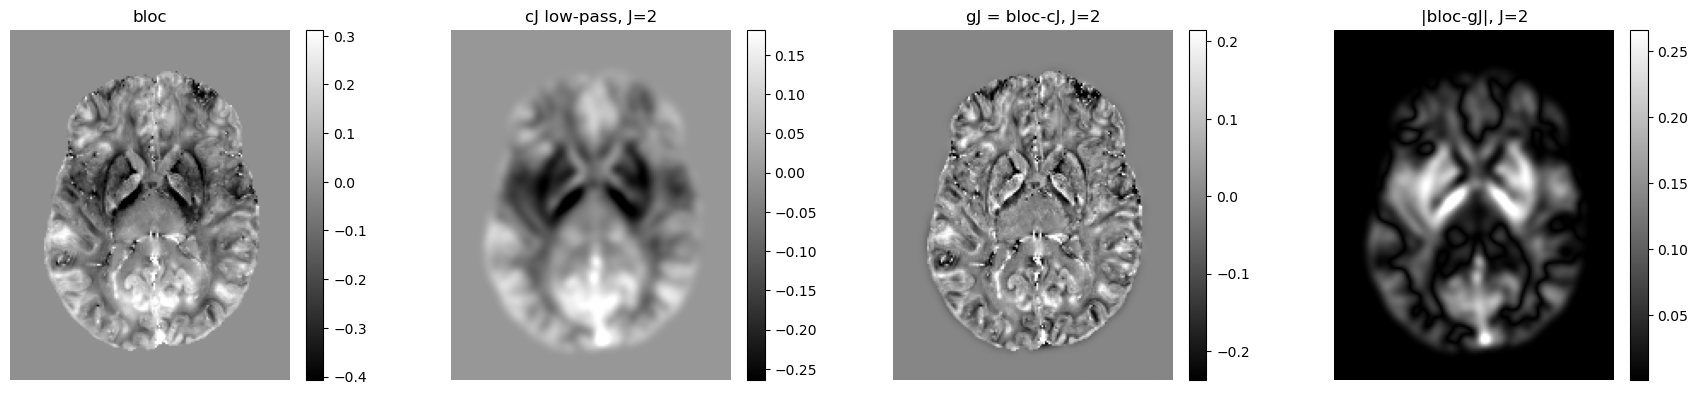

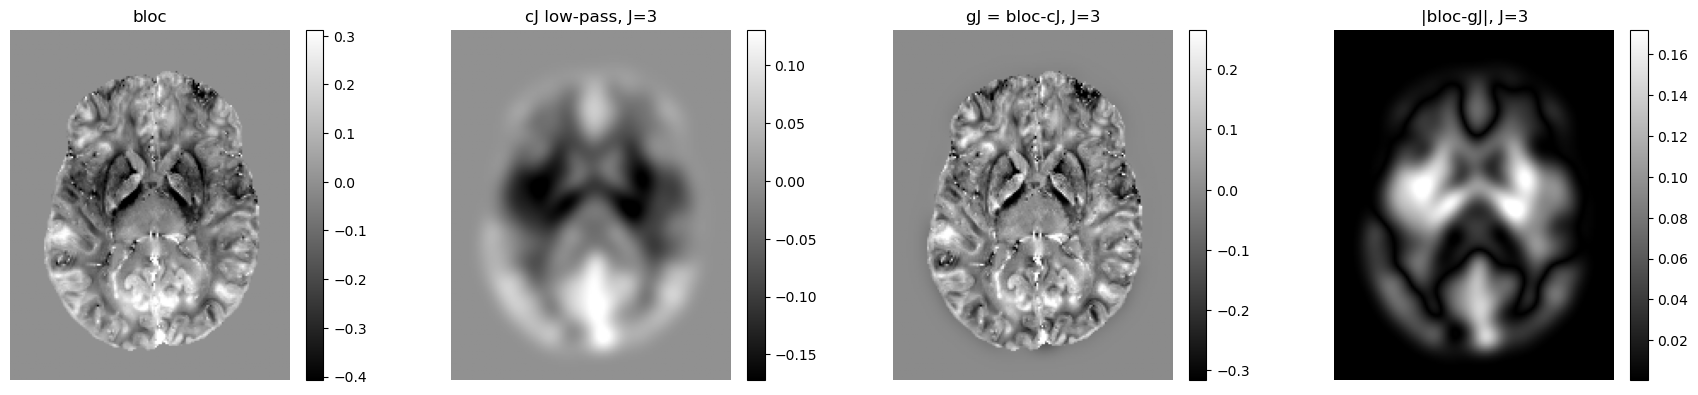

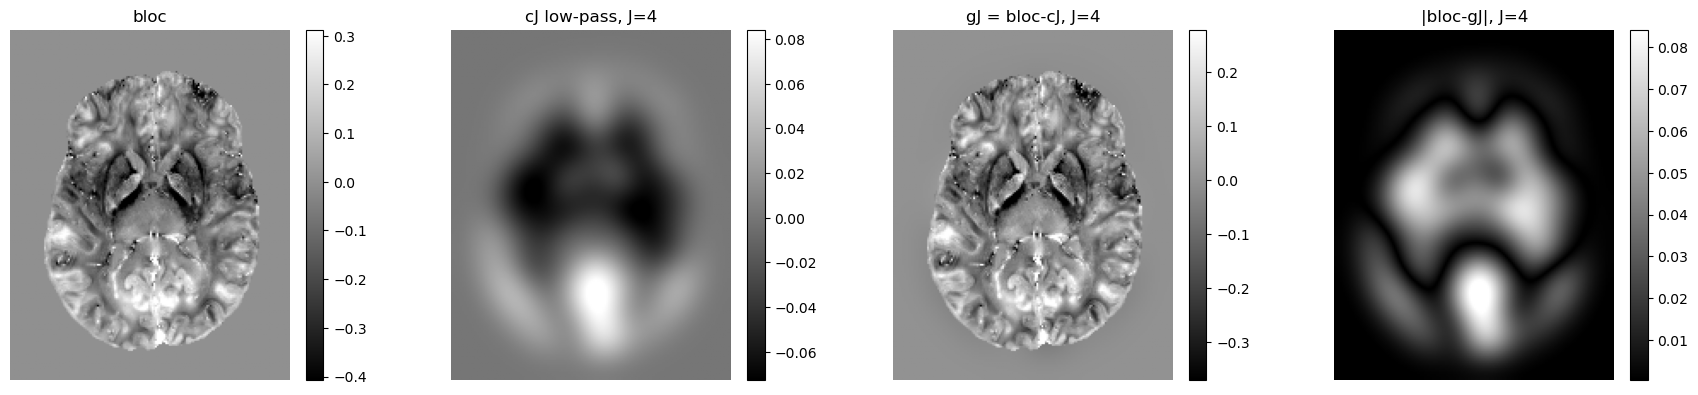

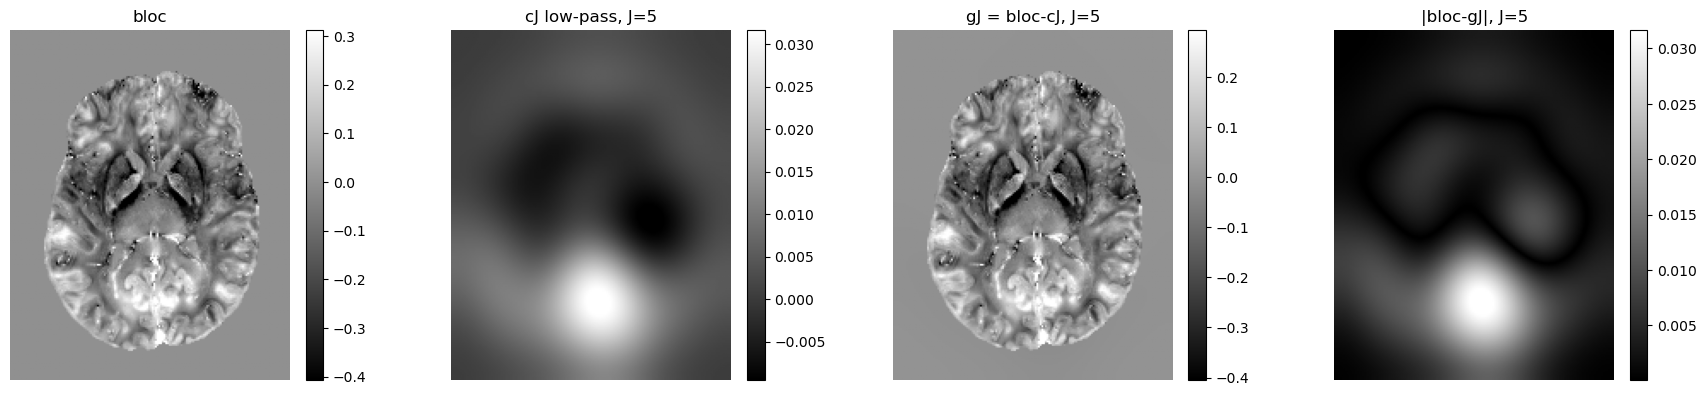

In [10]:
# Visualización por nivel J de la separación entre componente suave cJ
# y componente pasaaltos gJ
for J, res in local_results.items():
    fig = show_slices(
        [local_phase, res["cJ"], res["gJ"], np.abs(local_phase - res["gJ"])],
        [
            "bloc",
            f"cJ low-pass, J={J}",
            f"gJ = bloc-cJ, J={J}",
            f"|bloc-gJ|, J={J}",
        ],
        axis=axis,
        index=slice_idx,
        mask_for_limits=mask,
        figsize=(18,4),
    )

    # Guarda las figuras para su inclusión en el informe
    fig.savefig(RESULTS_DIR / f"part33_qsm_13-Vis_c_J-g_J_{J}.png", dpi=200, bbox_inches="tight")
    plt.show()

# 3.2 Deconvolución del operador equivalente

En esta sección se modela la operación multiescala como:

$$
g_J \approx (I - H_J)\, b_{\text{loc}},
$$

donde $H_J$ representa el operador pasa-bajos inducido por el residual de la transformada Starlet.

Para recuperar una estimación de $b_{\text{loc}}$ a partir de $g_J$, se considera la inversión del operador equivalente en el dominio de Fourier mediante regularización de Tikhonov:

$$
\hat{b} =
\mathcal{F}^{-1}
\left(
\frac{\overline{A}\, G}{|A|^2 + \alpha}
\right),
$$

donde:

- $G = \mathcal{F}(g_J)$;
- $A = 1 - H_J$ es la respuesta en frecuencia del operador pasaaltos;
- $\alpha > 0$ es el parámetro de regularización.

## Interpretación

La inversión del operador es inherentemente mal condicionada, ya que el filtro pasaaltos atenúa las componentes de baja frecuencia. Como consecuencia:

- valores pequeños de $\alpha$ pueden amplificar ruido y errores numéricos;
- valores grandes de $\alpha$ estabilizan la solución, pero introducen suavizado adicional;
- existe un compromiso entre fidelidad a la señal original y estabilidad de la reconstrucción.

Este comportamiento refleja la dificultad intrínseca de recuperar información de baja frecuencia a partir de una señal en la que dichas componentes han sido atenuadas, lo cual es consistente con problemas inversos asociados a operadores tipo SMV en QSM.

## 3.2.1 Estimación del operador pasaaltos equivalente

En esta sección se estima la respuesta en frecuencia del operador pasaaltos $A = I - H_J$ a partir de su respuesta al impulso.

Para ello, se aplica la operación Starlet a un impulso 3D centrado, obteniendo una aproximación discreta del kernel asociado al operador. Dado que el sistema puede interpretarse como lineal e invariante por traslación en el interior del volumen, esta respuesta al impulso permite caracterizar completamente el operador.

La transformada de Fourier de dicho kernel proporciona una estimación de la respuesta en frecuencia $A(\omega)$ utilizada posteriormente en la deconvolución.

Cabe destacar que esta construcción corresponde a una aproximación numérica del operador inducido por la Starlet, y no a un operador SMV físico exacto. Sin embargo, resulta consistente con el modelo utilizado en este notebook, permitiendo implementar una inversión coherente del operador pasaaltos multiescala.

In [11]:
# Se estima la respuesta del operador pasaaltos aplicándolo a un impulso.
# Esto permite construir una aproximación de A(k) = 1 - HJ(k) en Fourier
def estimate_highpass_response(shape, J, kernel="b3spline"):
    impulse = np.zeros(shape)
    center = tuple(s//2 for s in shape)
    impulse[center] = 1.0
    _, cJ_imp, _ = starlet_transform_3d(impulse, n_scales=J, kernel=kernel)
    h_high = impulse - cJ_imp
    h_high = np.fft.ifftshift(h_high)
    return fftn(h_high)

# Deconvolución regularizada tipo Tikhonov para invertir de forma estable
# el operador pasaaltos aproximado
def deconvolve_highpass(gJ, A, alpha=1e-3, mask=None):
    G = fftn(gJ)
    rec = np.real(ifftn(np.conj(A) * G / (np.abs(A)**2 + alpha)))
    if mask is not None:
        rec = rec * mask
    return rec

## 3.2.2 Deconvolución con distintos niveles y regularizaciones

Se evalúa la reconstrucción de $b_{\text{loc}}$ a partir de $g_J$ utilizando distintos valores de:

- $J$: nivel de escala;
- $\alpha$: parámetro de regularización de Tikhonov.

La tabla resume el error y la correlación entre la reconstrucción $\hat{b}$ y la fase local verdadera.

## Interpretación

Los resultados muestran que es posible recuperar la fase local con alta precisión para combinaciones adecuadas de $J$ y $\alpha$. En particular, para $J=4$ y $\alpha=10^{-4}$ se obtiene un RMSE muy bajo y una correlación prácticamente unitaria, lo que indica una reconstrucción casi perfecta.

Sin embargo, esta recuperación es altamente sensible al parámetro de regularización. Al aumentar $\alpha$, el error crece rápidamente y la correlación disminuye, reflejando el efecto de sobre-suavizado introducido por la regularización.

Asimismo, niveles menores de $J$ tienden a producir peores resultados, lo que sugiere que la calidad de la inversión depende también de la escala del operador considerado.

En conjunto, estos resultados evidencian el compromiso entre estabilidad y fidelidad en la deconvolución, característico de la inversión de operadores pasaaltos mal condicionados.

In [12]:
# Se evalúan niveles intermedios y distintos valores de alpha para estudiar
# el compromiso entre recuperación de señal y estabilidad numérica
DECONV_LEVELS = [3, 4]
ALPHAS = [1e-2, 1e-3, 1e-4]

deconv_results = {}
rows = []

# Para cada J se estima la respuesta del operador y se prueba la inversión
# regularizada con distintos niveles de regularización
for J in DECONV_LEVELS:
    print("Estimando respuesta para J =", J)
    A = estimate_highpass_response(local_phase.shape, J=J, kernel=KERNEL)
    gJ = local_results[J]["gJ"]

    for alpha in ALPHAS:
        b_hat = deconvolve_highpass(gJ, A, alpha=alpha, mask=mask)
        deconv_results[(J, alpha)] = b_hat
        rows.append({
            "J": J,
            "alpha": alpha,
            "RMSE_bhat_vs_bloc": masked_rmse(local_phase, b_hat, mask),
            "relative_RMSE_bhat_vs_bloc": relative_rmse(local_phase, b_hat, mask),
            "corr_bhat_vs_bloc": masked_corr(local_phase, b_hat, mask),
        })

df_32 = pd.DataFrame(rows).sort_values("RMSE_bhat_vs_bloc")
display(df_32)
df_32.to_csv(RESULTS_DIR / "part3_qsm_2_deconvolution_local.csv", index=False)

Estimando respuesta para J = 3
Estimando respuesta para J = 4


,J,alpha,RMSE_bhat_vs_bloc,relative_RMSE_bhat_vs_bloc,corr_bhat_vs_bloc
5,4,0.0001,0.001027,0.007280,0.999998
4,4,0.0010,0.002967,0.021033,0.999889
2,3,0.0001,0.003796,0.026909,0.999793
3,4,0.0100,0.010723,0.076001,0.997917
1,3,0.0010,0.012583,0.089191,0.996805
0,3,0.0100,0.032129,0.227730,0.976652


## 3.2.3 Visualización de la mejor reconstrucción deconvolucionada

Esta celda muestra la mejor reconstrucción obtenida en la sección anterior, correspondiente a la combinación óptima de $J$ y $\alpha$.

Se visualizan:

1. $b_{\text{loc}}$: fase local de referencia;
2. $g_J$: componente pasaaltos utilizada como entrada;
3. $\hat{b}$: volumen recuperado mediante deconvolución;
4. $|b_{\text{loc}} - \hat{b}|$: error absoluto.

## Interpretación

Se observa que la reconstrucción $\hat{b}$ reproduce con alta fidelidad la estructura de la fase local, siendo prácticamente indistinguible de la referencia en la mayoría del volumen. El error absoluto es de baja magnitud y presenta una estructura suave, lo que indica que las diferencias se concentran principalmente en componentes de baja frecuencia.

Este resultado es consistente con el análisis teórico: aunque la inversión del operador pasaaltos permite recuperar gran parte de la señal, las componentes de baja frecuencia son las más difíciles de reconstruir debido a la atenuación inducida por el filtrado.

En consecuencia, la deconvolución logra una recuperación muy precisa de las variaciones locales, mientras que las discrepancias residuales reflejan la naturaleza mal condicionada del problema inverso en bajas frecuencias.

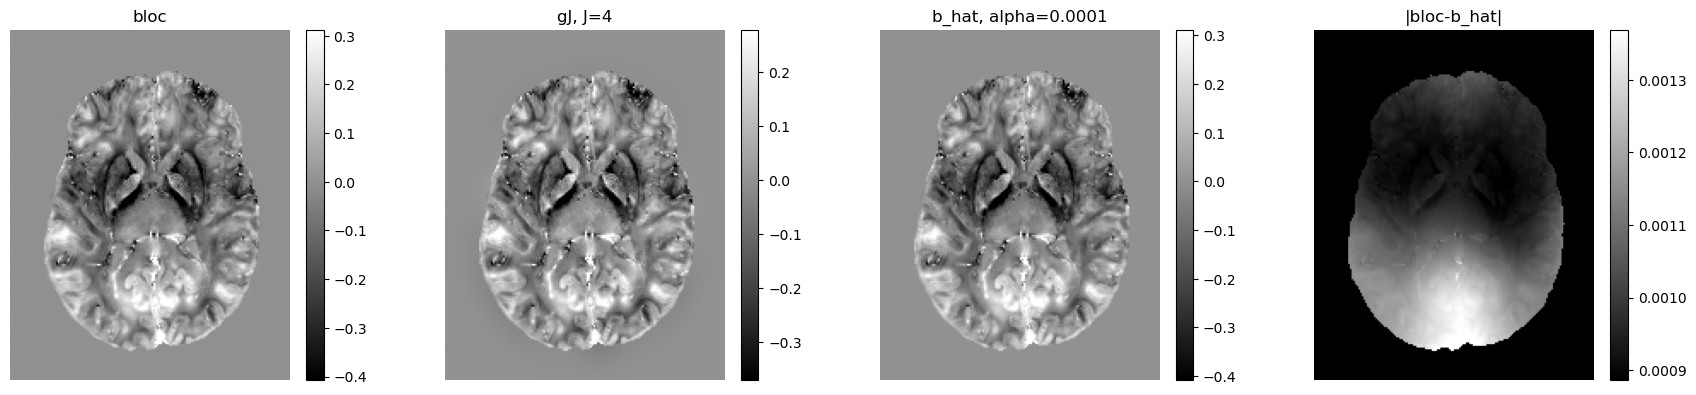

In [13]:
# Se selecciona la configuración con menor RMSE para visualizar una
# reconstrucción representativa de la deconvolución
best = df_32.iloc[0]
best_J = int(best["J"])
best_alpha = float(best["alpha"])
b_hat_best = deconv_results[(best_J, best_alpha)]

fig = show_slices(
    [
        local_phase,
        local_results[best_J]["gJ"],
        b_hat_best,
        np.abs(local_phase - b_hat_best),
    ],
    [
        "bloc",
        f"gJ, J={best_J}",
        f"b_hat, alpha={best_alpha}",
        "|bloc-b_hat|",
    ],
    axis=axis,
    index=slice_idx,
    mask_for_limits=mask,
    figsize=(18,4),
)

# Guarda la figura para su inclusión en el informe
fig.savefig(RESULTS_DIR / f"part33_qsm_23-bloc_gJ_J{best_J}.png", dpi=200, bbox_inches="tight")
plt.show()

# 3.3 Aplicación a la fase total

En esta sección se aplica el mismo procedimiento a la fase total (`total_phase`), con el fin de analizar cómo la descomposición multiescala separa componentes locales y de fondo.

A partir de la transformada Starlet 3D, se construye:

$$
g_J^{(\text{total})} = b_{\text{total}} - c_J^{(\text{total})},
$$

donde $c_J^{(\text{total})}$ representa el residual suave de la fase total.

Este resultado se compara con el obtenido para la fase local verdadera, con el objetivo de identificar diferencias en la distribución multiescala de la señal.

## Interpretación

Dado que la fase total contiene tanto la componente local como el campo de fondo, se espera que el residual $c_J^{(\text{total})}$ capture una mayor proporción de estructuras suaves de gran escala en comparación con el caso de la fase local.

En consecuencia, la componente pasaaltos $g_J^{(\text{total})}$ debería diferir de $g_J^{(\text{local})}$ en aquellas regiones donde existen contribuciones de fondo no completamente eliminadas.

Asimismo, es posible que ciertas estructuras o artefactos de alta frecuencia permanezcan en $g_J^{(\text{total})}$, ya que el operador pasaaltos conserva variaciones locales independientemente de su origen físico.

En conjunto, esta comparación permite evaluar en qué medida la descomposición Starlet logra separar componentes locales y de fondo en la fase total, y cuáles son las limitaciones de esta aproximación frente a un operador SMV ideal.

## 3.3.1 Cálculo de $g_J$ para la fase total

En esta sección se calcula la componente pasaaltos $g_J^{(\text{total})}$ y el residual suave $c_J^{(\text{total})}$ para distintos niveles de descomposición, utilizando la fase total como entrada.

Estos resultados permiten comparar directamente la descomposición multiescala de la fase total con la obtenida para la fase local, analizando las diferencias en la separación entre componentes suaves y locales.

In [14]:
# Se repite la construcción de gJ sobre la fase total para evaluar cuánto
# del campo de fondo es removido al descartar el residual suave
total_results = {}

for J in N_SCALES_LIST:
    print("Procesando fase total btot, J =", J)
    gJ, cJ, details = starlet_highpass(total_phase, J=J, kernel=KERNEL)
    total_results[J] = {"gJ": gJ, "cJ": cJ, "details": details}

Procesando fase total btot, J = 2
Procesando fase total btot, J = 3
Procesando fase total btot, J = 4
Procesando fase total btot, J = 5


## 3.3.2 Métricas entre fase total filtrada y fase local filtrada

Esta tabla compara la componente pasaaltos obtenida a partir de la fase total, $g_J^{(\text{total})}$, con la correspondiente de la fase local, $g_J^{(\text{local})}$.

Columnas principales:

- `RMSE_total_gJ_vs_local_gJ`: diferencia absoluta entre ambas componentes pasaaltos;
- `relative_RMSE_total_gJ_vs_local_gJ`: error relativo normalizado;
- `corr_total_gJ_vs_local_gJ`: correlación entre ambas señales;
- `energy_total_gJ`: energía retenida en el pasaaltos de la fase total;
- `energy_total_cJ`: energía capturada por el residual suave de la fase total.

## Interpretación

Los resultados muestran que la diferencia entre $g_J^{(\text{total})}$ y $g_J^{(\text{local})}$ aumenta sistemáticamente con el nivel $J$. En particular, el RMSE crece y la correlación disminuye, lo que indica que ambas señales se vuelven progresivamente menos similares a medida que se incrementa la escala del filtrado.

Este comportamiento sugiere que el residual $c_J^{(\text{total})}$ no captura completamente las componentes de fondo presentes en la fase total. Como consecuencia, parte de estas componentes permanece en $g_J^{(\text{total})}$, afectando la comparación con la fase local.

Además, el aumento de la energía en $g_J^{(\text{total})}$ con $J$ refuerza la idea de que el filtrado multiescala no está eliminando eficazmente las contribuciones de baja frecuencia asociadas al campo de fondo.

En conjunto, estos resultados evidencian que la aproximación basada en Starlet no reproduce completamente el comportamiento de un operador SMV ideal, especialmente en escalas grandes, donde las diferencias entre fase total y fase local se vuelven más pronunciadas.

In [15]:
# Comparación entre la componente pasaaltos de la fase total y la obtenida
# desde la fase local verdadera para el mismo nivel J
rows = []
for J in N_SCALES_LIST:
    rows.append({
        "J": J,
        "RMSE_total_gJ_vs_local_gJ": masked_rmse(local_results[J]["gJ"], total_results[J]["gJ"], mask),
        "relative_RMSE_total_gJ_vs_local_gJ": relative_rmse(local_results[J]["gJ"], total_results[J]["gJ"], mask),
        "corr_total_gJ_vs_local_gJ": masked_corr(local_results[J]["gJ"], total_results[J]["gJ"], mask),
        "energy_total_gJ": masked_energy(total_results[J]["gJ"], mask),
        "energy_total_cJ": masked_energy(total_results[J]["cJ"], mask),
    })

df_33 = pd.DataFrame(rows)
display(df_33)
df_33.to_csv(RESULTS_DIR / "part3_qsm_3_total_phase_highpass_metrics.csv", index=False)

,J,RMSE_total_gJ_vs_local_gJ,relative_RMSE_total_gJ_vs_local_gJ,corr_total_gJ_vs_local_gJ,energy_total_gJ,energy_total_cJ
0,2,0.422246,4.607976,0.196890,0.185420,1.869382
1,3,0.650546,5.795543,0.164738,0.434958,1.310180
2,4,0.999531,7.903187,0.114154,1.012013,0.590861
3,5,1.402553,10.267575,0.078949,1.978714,0.101260


## 3.3.3 Visualización de la fase total filtrada

Cada fila de figuras muestra, para un nivel $J$:

1. $b_{\text{total}}$: fase total original;
2. $c_J^{(\text{total})}$: componente suave asociada al residual;
3. $g_J^{(\text{total})}$: componente pasaaltos retenido;
4. $|g_J^{(\text{local})} - g_J^{(\text{total})}|$: diferencia entre la fase total filtrada y la fase local filtrada.

## Interpretación

Las visualizaciones muestran que el residual $c_J^{(\text{total})}$ captura principalmente las estructuras suaves de gran escala asociadas al campo de fondo, incluyendo regiones de alta intensidad global.

Sin embargo, la componente pasaaltos $g_J^{(\text{total})}$ aún contiene estructuras que no están presentes en $g_J^{(\text{local})}$. Esto se evidencia claramente en los mapas de diferencia, donde aparecen discrepancias significativas, especialmente en regiones cercanas al borde del cerebro y en zonas con fuerte gradiente global.

Además, a medida que aumenta el nivel $J$, estas diferencias se intensifican, lo que indica que el filtrado multiescala elimina progresivamente componentes suaves, pero no logra separar completamente el campo de fondo de la señal local.

En conjunto, estas observaciones confirman que la aproximación basada en Starlet actúa como un filtrado pasaaltos efectivo, pero no equivalente a un operador SMV ideal, ya que deja residuos estructurados del campo de fondo en la componente retenida.

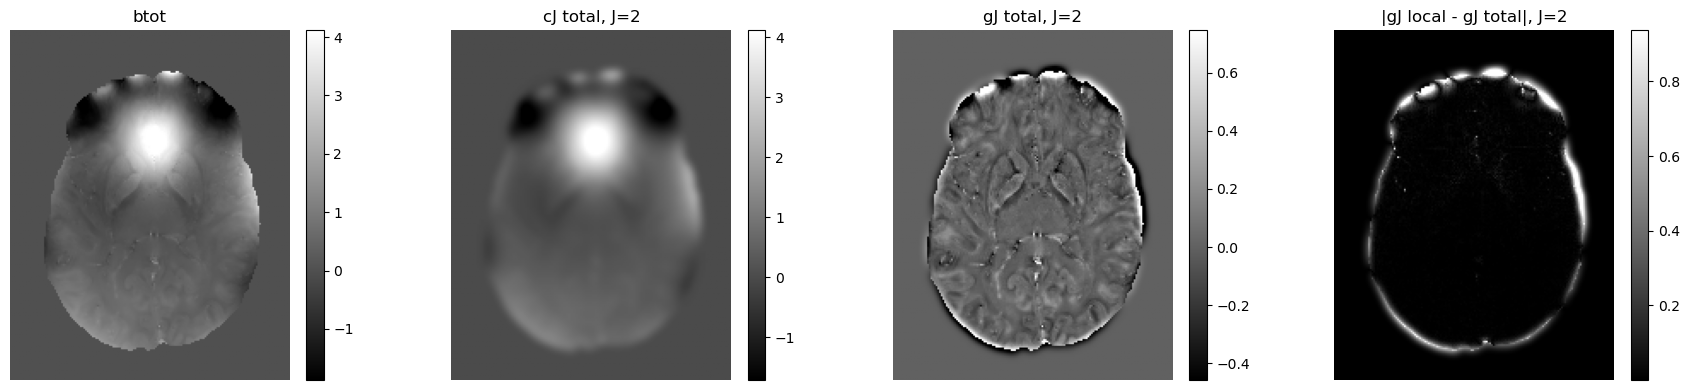

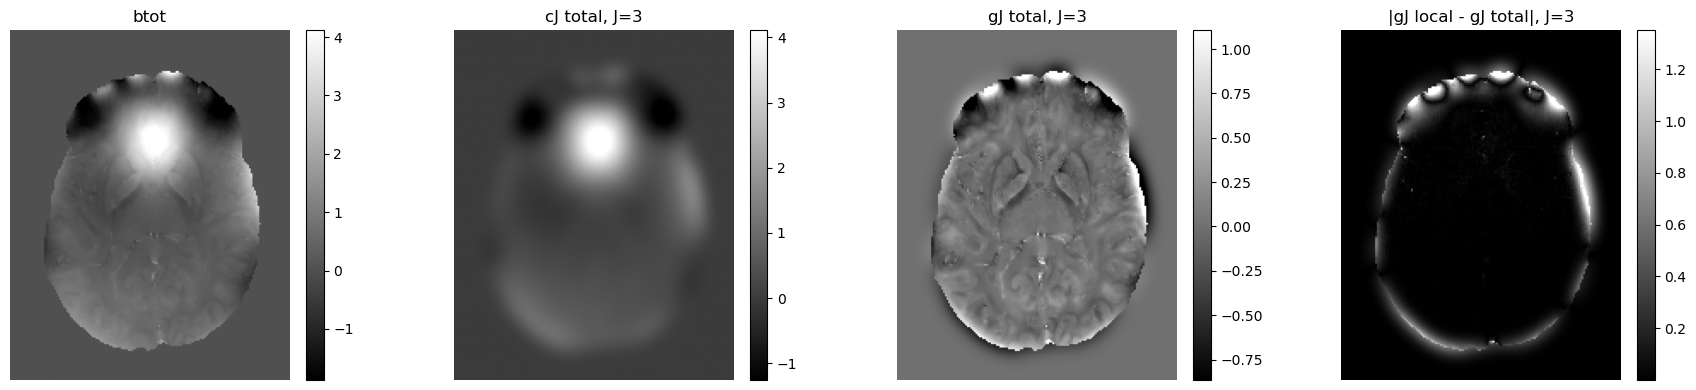

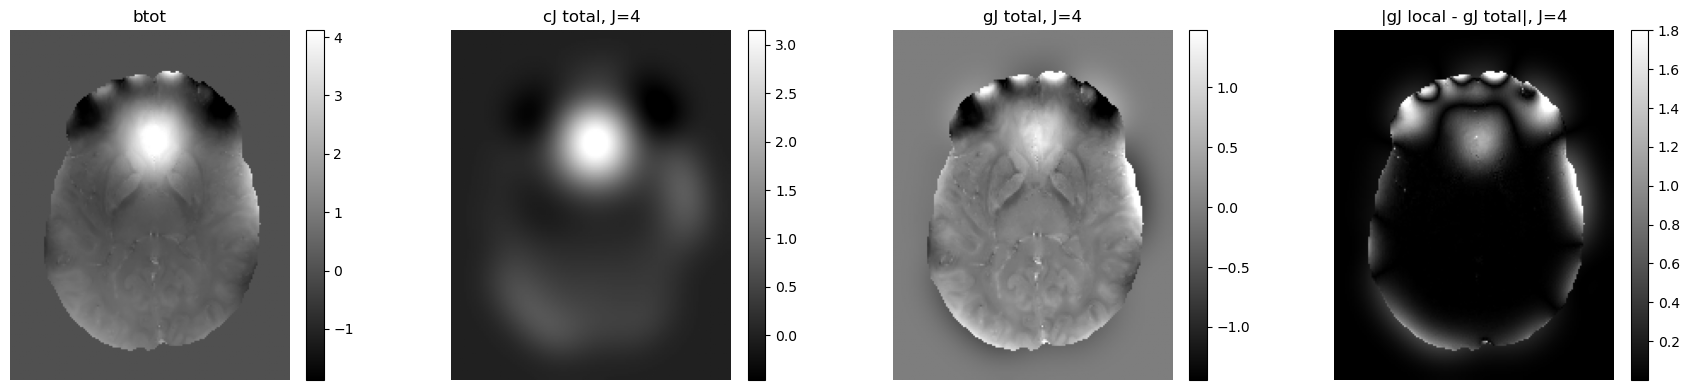

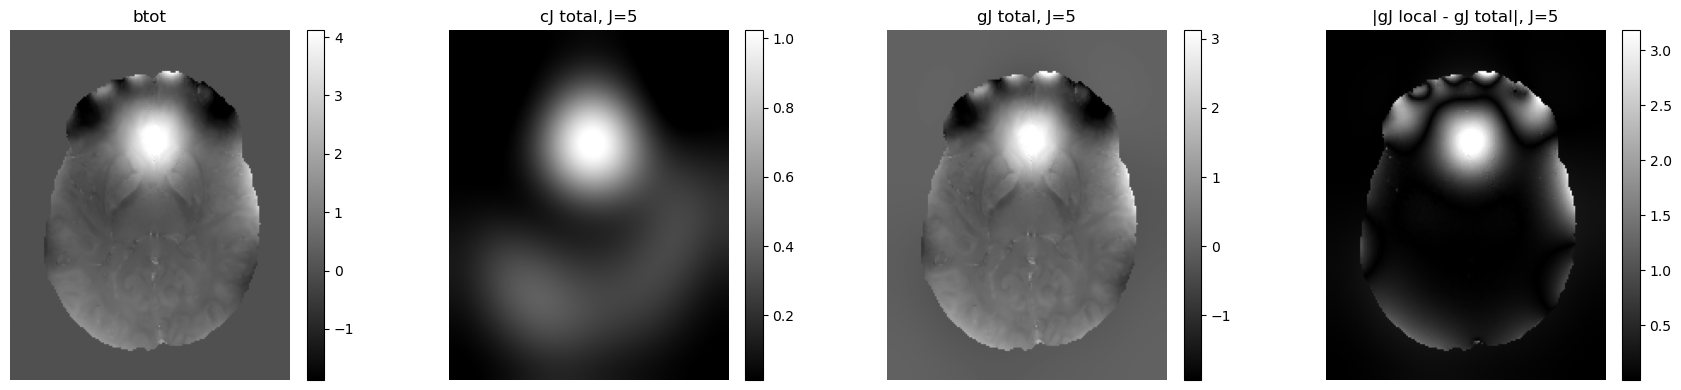

In [16]:
# Se analiza cómo la descomposición Starlet de la fase total se separa en
# componente suave (cJ) y pasaaltos (gJ), y se compara con la fase local
# para evaluar el efecto del campo de fondo
for J in N_SCALES_LIST:
    fig = show_slices(
        [
            total_phase,
            total_results[J]["cJ"],
            total_results[J]["gJ"],
            np.abs(local_results[J]["gJ"] - total_results[J]["gJ"]),
        ],
        [
            "btot",
            f"cJ total, J={J}",
            f"gJ total, J={J}",
            f"|gJ local - gJ total|, J={J}",
        ],
        axis=axis,
        index=slice_idx,
        mask_for_limits=mask,
        figsize=(18,4),
    )

    # Guarda las figuras para su inclusión en el informe
    fig.savefig(RESULTS_DIR / f"part33_qsm_33-btot_cJ_J{J}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 3.3.4 Comparación adicional con V-SHARP

Esta subparte complementa el análisis anterior utilizando la estimación `vsharp_local` para evaluar el comportamiento de la descomposición Starlet sobre una señal donde el campo de fondo ha sido previamente reducido.

En particular, se compara la componente pasaaltos $g_J^{(\text{vsharp})}$ con $g_J^{(\text{local})}$, calculada a partir de la fase local verdadera.

## Interpretación

Los resultados muestran que la componente pasaaltos obtenida a partir de V-SHARP presenta una alta similitud con la correspondiente de la fase local verdadera. En particular, los valores de RMSE se mantienen bajos en todos los niveles de escala, mientras que la correlación se mantiene alta, cercana a 0.85–0.88.

A diferencia de lo observado en la fase total, donde las discrepancias aumentan significativamente con $J$, en este caso la diferencia entre $g_J^{(\text{vsharp})}$ y $g_J^{(\text{local})}$ se mantiene acotada y relativamente estable.

Esto sugiere que V-SHARP logra eliminar de manera efectiva una parte importante del campo de fondo, permitiendo que la descomposición multiescala capture principalmente componentes locales.

En conjunto, estos resultados indican que la aproximación Starlet es consistente con la fase local cuando el fondo ha sido previamente reducido, pero no es suficiente por sí sola para realizar una separación equivalente a métodos específicos como V-SHARP o SMV.

In [17]:
# V-SHARP se usa como referencia adicional porque ya incluye una etapa
# de remoción de campo de fondo
comparison_names = ["vsharp_local"]
comparison_results = {}

for name in comparison_names:
    comparison_results[name] = {}
    vol = comparison_volumes[name]
    for J in N_SCALES_LIST:
        gJ, cJ, _ = starlet_highpass(vol, J=J, kernel=KERNEL)
        comparison_results[name][J] = {"gJ": gJ, "cJ": cJ}

# Se compara el pasaaltos de V-SHARP con el pasaaltos de la fase local
# verdadera para evaluar si ambos concentran estructuras similares
rows = []
for name in comparison_names:
    for J in N_SCALES_LIST:
        rows.append({
            "volume": name,
            "J": J,
            "RMSE_gJ_vs_local_gJ": masked_rmse(local_results[J]["gJ"], comparison_results[name][J]["gJ"], mask),
            "relative_RMSE_gJ_vs_local_gJ": relative_rmse(local_results[J]["gJ"], comparison_results[name][J]["gJ"], mask),
            "corr_gJ_vs_local_gJ": masked_corr(local_results[J]["gJ"], comparison_results[name][J]["gJ"], mask),
        })

df_33_extra = pd.DataFrame(rows).sort_values(["J", "RMSE_gJ_vs_local_gJ"])
display(df_33_extra)
df_33_extra.to_csv(RESULTS_DIR / "part3_qsm_3_vsharp_highpass_comparison.csv", index=False)

,volume,J,RMSE_gJ_vs_local_gJ,relative_RMSE_gJ_vs_local_gJ,corr_gJ_vs_local_gJ
0,vsharp_local,2,0.046994,0.512843,0.859731
1,vsharp_local,3,0.054173,0.482616,0.876175
2,vsharp_local,4,0.063325,0.500701,0.865689
3,vsharp_local,5,0.072297,0.529260,0.848632


# 3.4 Discusión de bordes y propuesta de solución

Los métodos basados en SMV presentan degradación cerca de los bordes del dominio debido a la imposibilidad de evaluar completamente el promedio esférico cuando la vecindad se extiende fuera de la máscara. En términos prácticos, esto introduce sesgos sistemáticos en la estimación del campo de fondo en regiones cercanas al límite.

Una situación análoga ocurre en la aproximación basada en Starlet. Dado que la transformada se implementa mediante convoluciones multiescala, las respuestas cercanas al borde combinan información del interior con valores externos (típicamente cero o padding implícito), lo que introduce artefactos y distorsiona tanto las componentes suaves como los detalles.

Este efecto es consistente con lo observado en secciones anteriores, donde las diferencias entre $g_J^{(\text{total})}$ y $g_J^{(\text{local})}$ se concentran principalmente en regiones cercanas al borde de la máscara.

## Estrategia implementada

Para analizar este fenómeno de manera controlada, se implementa una estrategia basada en la separación del dominio:

1. se erosiona la máscara original para definir una **región interior confiable**, donde los efectos de borde son mínimos;
2. se define una **región de borde** como la diferencia entre la máscara original y la erosionada;
3. se calculan métricas de error y similitud de forma independiente en ambas regiones;
4. se comparan los resultados para evaluar el impacto de los bordes en el desempeño del método.

## Interpretación

Esta estrategia no modifica los volúmenes ni corrige los artefactos, pero permite aislar el efecto de los bordes en las métricas. En particular, permite distinguir entre errores intrínsecos del método en el interior del dominio y errores inducidos por condiciones de borde.

En el contexto de QSM, esta separación es especialmente relevante, ya que muchos métodos (incluyendo SMV y sus variantes) están definidos idealmente en dominios sin borde o con condiciones periódicas, mientras que en la práctica se aplican sobre regiones finitas delimitadas por máscaras anatómicas.

## 3.4.1 Definición de región interior y región de borde

A partir de la máscara original se construyen dos regiones complementarias mediante una erosión morfológica:

- la **región interior**, definida como la máscara erosionada, que corresponde a un subconjunto del dominio suficientemente alejado del borde;
- la **región de borde**, definida como la diferencia entre la máscara original y la máscara erosionada.

## Interpretación

La región interior representa el dominio donde las operaciones de filtrado (tanto SMV como la aproximación Starlet) pueden evaluarse de manera más confiable, sin influencia significativa de condiciones de borde.

Por el contrario, la región de borde corresponde a una banda donde las convoluciones multiescala y los promedios locales se ven afectados por la falta de información fuera de la máscara. En estas zonas, los operadores tienden a mezclar valores internos con padding implícito, generando artefactos y errores sistemáticos.

Esta partición permite analizar de forma separada el comportamiento del método en condiciones ideales (interior) y en condiciones adversas (borde).

mask voxels: 1332273
inner voxels: 1164848
border voxels: 167425


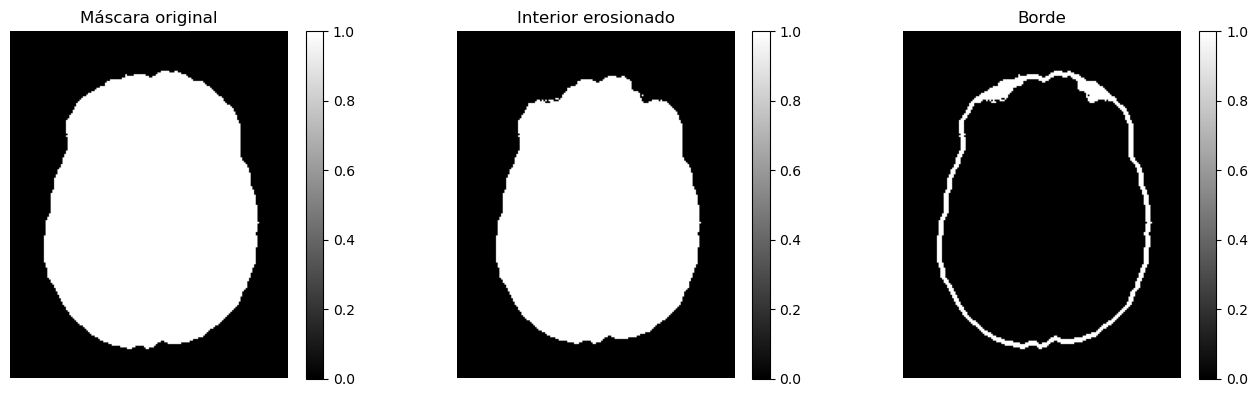

In [18]:
# La máscara erosionada define una región interior más confiable,
# mientras que la diferencia con la máscara original define el borde
EROSION_ITERATIONS = 3
inner_mask = binary_erosion(mask, iterations=EROSION_ITERATIONS)
border_mask = mask & (~inner_mask)

print("mask voxels:", int(mask.sum()))
print("inner voxels:", int(inner_mask.sum()))
print("border voxels:", int(border_mask.sum()))

fig=show_slices(
    [mask.astype(float), inner_mask.astype(float), border_mask.astype(float)],
    ["Máscara original", "Interior erosionado", "Borde"],
    axis=axis,
    index=slice_idx,
    cmap="gray",
    figsize=(14,4),
)

# Guarda la figura para su inclusión en el informe
fig.savefig(RESULTS_DIR / f"part33_41-mask_inter_border.png", dpi=200, bbox_inches="tight")
plt.show()

## 3.4.2 Comparación de error en interior vs borde

Esta tabla compara la diferencia entre $g_J^{(\text{total})}$ y $g_J^{(\text{local})}$ en dos regiones del dominio:

- la **región interior erosionada**, donde los efectos de borde son mínimos;
- la **región de borde**, donde las operaciones de filtrado se ven afectadas por la falta de información fuera de la máscara.

## Interpretación

Los resultados muestran una diferencia significativa entre ambas regiones. En todos los niveles de escala $J$, el error en la región de borde es considerablemente mayor que en el interior. En particular, el RMSE en el borde puede ser un orden de magnitud superior al del interior, lo que indica que la degradación del método está fuertemente concentrada en estas zonas.

Además, la correlación en la región de borde se mantiene muy baja para todos los niveles, lo que sugiere una pérdida importante de estructura en comparación con la fase local. En contraste, en la región interior la correlación es mayor y decrece de manera más progresiva con $J$.

Este comportamiento confirma que gran parte de la discrepancia observada entre $g_J^{(\text{total})}$ y $g_J^{(\text{local})}$ no proviene únicamente de limitaciones del filtrado multiescala, sino también de efectos de borde inherentes al uso de máscaras finitas.

En consecuencia, la evaluación global del método puede estar dominada por errores en regiones cercanas al borde, por lo que resulta fundamental analizar separadamente el interior del dominio para obtener una estimación más representativa del desempeño real.

In [19]:
# Se reportan métricas separadas en interior y borde para cuantificar
# la degradación del operador cerca de la frontera de la máscara
rows = []
for J in N_SCALES_LIST:
    ref = local_results[J]["gJ"]
    est = total_results[J]["gJ"]

    rows.append({
        "J": J,
        "RMSE_inner_total_vs_local_gJ": masked_rmse(ref, est, inner_mask),
        "RMSE_border_total_vs_local_gJ": masked_rmse(ref, est, border_mask),
        "corr_inner": masked_corr(ref, est, inner_mask),
        "corr_border": masked_corr(ref, est, border_mask),
    })

df_34 = pd.DataFrame(rows)
display(df_34)
df_34.to_csv(RESULTS_DIR / "part3_qsm_4_border_inner_metrics.csv", index=False)

,J,RMSE_inner_total_vs_local_gJ,RMSE_border_total_vs_local_gJ,corr_inner,corr_border
0,2,0.087780,1.168389,0.692884,0.077835
1,3,0.319124,1.630680,0.312663,0.082012
2,4,0.698116,2.135216,0.155172,0.071276
3,5,1.133547,2.591078,0.093976,0.054363


## 3.4.3 Gráfico comparativo de borde vs interior

Este gráfico resume visualmente la diferencia de error entre la región interior erosionada y la región de borde para distintos niveles de escala $J$.

## Interpretación

Se observa que el error en la región de borde es significativamente mayor que en el interior para todos los niveles, y que esta diferencia aumenta a medida que crece $J$. Mientras el RMSE en el interior presenta un incremento progresivo, el RMSE en el borde crece de manera más pronunciada, evidenciando que la degradación del método está fuertemente concentrada en estas zonas.

Esta tendencia confirma que los efectos de borde no solo introducen error adicional, sino que además dominan el comportamiento global del método en escalas grandes.

## Implicancia práctica

Dado que las métricas globales pueden estar fuertemente influenciadas por errores en el borde, resulta recomendable reportar también resultados restringidos a la región interior erosionada. Esto permite obtener una evaluación más representativa del desempeño del método en condiciones donde las hipótesis del modelo (convolución local, ausencia de truncamiento) son más válidas.

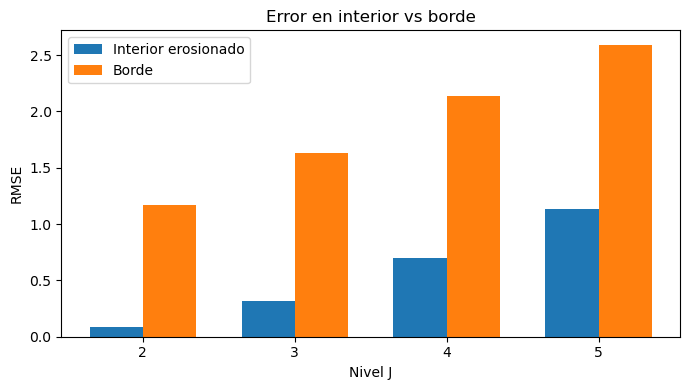

In [20]:
# Figura resumen para comparar visualmente el error en interior y borde
plt.figure(figsize=(7,4))
x = np.arange(len(df_34))
width = 0.35
plt.bar(x - width/2, df_34["RMSE_inner_total_vs_local_gJ"], width, label="Interior erosionado")
plt.bar(x + width/2, df_34["RMSE_border_total_vs_local_gJ"], width, label="Borde")
plt.xticks(x, df_34["J"])
plt.xlabel("Nivel J")
plt.ylabel("RMSE")
plt.title("Error en interior vs borde")
plt.legend()
plt.tight_layout()

# Guarda la figura para su inclusión en el informe
save_current_fig(f"part33_qsm_43-Error_en_interior_vs_borde.png")
plt.show()

# 3.5 Uso de la MMT en la aproximación a SMV

La transformada MMT (Median Multiscale Transform) permite construir una descomposición multiescala basada en filtrado de mediana iterado. A diferencia de la Starlet, esta transformada es **no lineal**, lo que implica que no admite una representación simple en el dominio de Fourier ni una respuesta en frecuencia bien definida.

En particular, no es posible escribir un operador equivalente del tipo $H_J(k)$ ni formular directamente una inversión tipo SHARP/RESHARP. Esto limita su uso para construir aproximaciones explícitas de operadores físicos basados en convolución, como el SMV.

No obstante, es posible definir una componente pasaaltos de manera análoga:

$$
g_J^{(\text{MMT})} = b - c_J^{(\text{MMT})},
$$

donde $c_J^{(\text{MMT})}$ corresponde a la componente suave obtenida mediante filtrado de mediana multiescala.

## Interpretación

A diferencia de la Starlet, que actúa como un filtro lineal pasaaltos, la MMT tiende a preservar estructuras locales y bordes de forma más robusta, debido a la naturaleza del filtro de mediana. Esto puede resultar en una mejor conservación de discontinuidades, pero también implica que la separación entre componentes suaves y de alta frecuencia no sigue un modelo espectral claro.

En consecuencia, la componente $g_J^{(\text{MMT})}$ no puede interpretarse directamente como una aproximación de un operador SMV, sino más bien como una descomposición estructural basada en orden estadístico local.

## Qué se busca evaluar

Esta comparación exploratoria permite analizar:

- si la MMT produce una separación cualitativa entre componentes suaves y locales comparable a la Starlet;
- si la preservación de bordes difiere entre ambos enfoques, especialmente en regiones cercanas al límite de la máscara;
- si la MMT podría ser útil como herramienta complementaria para análisis multiescala, aun cuando no sea adecuada para modelar operadores físicos como SMV.

## Conclusión esperada

Dado su carácter no lineal, la MMT no es directamente equivalente a métodos basados en convolución como SMV o Starlet. Sin embargo, puede ofrecer ventajas en la preservación de estructuras locales, lo que la convierte en una alternativa interesante desde el punto de vista cualitativo, aunque no como sustituto directo en el marco de QSM.

## 3.5.1 Construcción de una componente pasaaltos basada en MMT

En esta sección se construye una componente pasaaltos utilizando la descomposición multiescala basada en filtrado de mediana (MMT).

De manera análoga al caso de la Starlet, se define:

$$
g_J^{(\text{MMT})} = b - c_J^{(\text{MMT})},
$$

donde $c_J^{(\text{MMT})}$ corresponde a la componente suave obtenida mediante filtrado de mediana iterado hasta el nivel $J$.

A diferencia de la Starlet, esta construcción no proviene de un operador lineal bien definido, por lo que debe interpretarse como una aproximación **exploratoria** de un pasaaltos multiescala, basada en propiedades locales de la señal más que en su contenido espectral.

## Interpretación

Esta construcción permite comparar directamente $g_J^{(\text{MMT})}$ con la componente pasaaltos obtenida mediante Starlet, evaluando en qué medida ambas transformadas generan descomposiciones similares.

Los resultados muestran que existe una alta similitud entre ambas representaciones en niveles bajos de escala, con valores de correlación elevados. Sin embargo, a medida que aumenta $J$, la diferencia entre ambas aproximaciones crece, lo que indica que la MMT y la Starlet separan de manera distinta las componentes suaves y locales en escalas más gruesas.

En particular, la MMT tiende a preservar estructuras locales de manera más robusta, mientras que la Starlet produce una separación más consistente con un modelo de filtrado pasaaltos lineal.

In [21]:
# Aproximación no lineal basada en filtros de mediana sucesivos.
# A diferencia de Starlet, esta construcción no tiene respuesta en frecuencia
# bien definida
def mmt_lowpass_3d(volume, J, size=3):
    c = np.asarray(volume, dtype=float).copy()
    for _ in range(J):
        c = median_filter(c, size=size, mode="reflect")
    return c

rows = []
mmt_results = {}

# Se construye un pasaaltos MMT análogo a gJ para comparar su comportamiento
# con el pasaaltos Starlet sobre la fase local
for J in N_SCALES_LIST:
    cJ_mmt = mmt_lowpass_3d(local_phase, J=J, size=3)
    gJ_mmt = local_phase - cJ_mmt
    mmt_results[J] = {"cJ": cJ_mmt, "gJ": gJ_mmt}

    rows.append({
        "J": J,
        "RMSE_mmt_gJ_vs_starlet_gJ": masked_rmse(local_results[J]["gJ"], gJ_mmt, mask),
        "corr_mmt_gJ_vs_starlet_gJ": masked_corr(local_results[J]["gJ"], gJ_mmt, mask),
        "energy_mmt_gJ": masked_energy(gJ_mmt, mask),
    })

df_35 = pd.DataFrame(rows)
display(df_35)
df_35.to_csv(RESULTS_DIR / "part3_qsm_5_mmt_vs_starlet.csv", index=False)

,J,RMSE_mmt_gJ_vs_starlet_gJ,corr_mmt_gJ_vs_starlet_gJ,energy_mmt_gJ
0,2,0.038492,0.917585,0.005134
1,3,0.061463,0.854894,0.005825
2,4,0.077916,0.807220,0.006368
3,5,0.089646,0.773039,0.006830


## 3.5.2 Comparación visual entre Starlet y MMT

La figura muestra, para un nivel representativo ($J=4$):

1. la fase local verdadera (`bloc`);
2. la componente pasaaltos obtenida mediante Starlet, $g_J^{(\text{Starlet})}$;
3. la componente pasaaltos obtenida mediante MMT, $g_J^{(\text{MMT})}$;
4. la diferencia absoluta $|g_J^{(\text{Starlet})} - g_J^{(\text{MMT})}|$.

## Interpretación

Ambas aproximaciones generan componentes pasaaltos cualitativamente similares, preservando estructuras anatómicas relevantes y variaciones locales de alta frecuencia.

Sin embargo, la diferencia entre ambas no es despreciable y presenta patrones estructurados:

- las discrepancias se concentran en bordes y regiones con alta curvatura;
- la MMT tiende a suavizar o modificar ciertas estructuras locales en comparación con la Starlet;
- la Starlet mantiene una respuesta más coherente con un filtrado lineal multiescala, mientras que la MMT responde de forma no lineal a outliers y variaciones locales.

Esto confirma que, aunque ambas transformadas pueden utilizarse para construir una componente pasaaltos, **no son equivalentes**, especialmente en escalas medias y gruesas.

## Conclusión

La MMT puede ser una alternativa útil para resaltar estructuras locales, pero su naturaleza no lineal implica que no reproduce fielmente el operador pasaaltos inducido por la Starlet ni una aproximación directa a SMV.

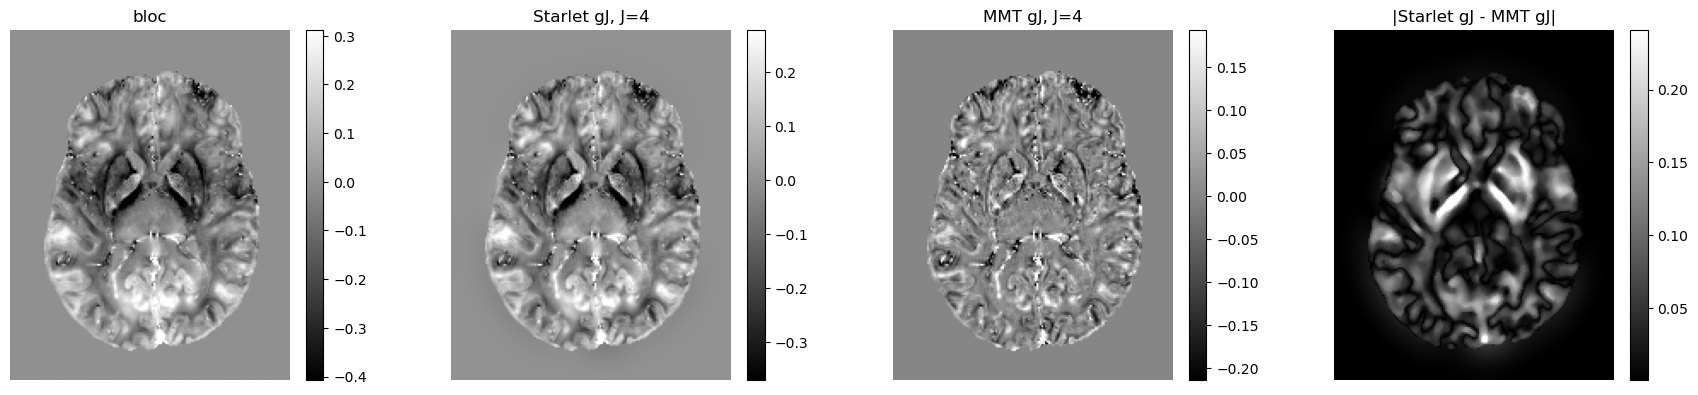

In [22]:
# Se usa un nivel representativo para comparar visualmente las diferencias
# entre el pasaaltos lineal de Starlet y el pasaaltos no lineal de MMT
J_VIS = 4
fig = show_slices(
    [
        local_phase,
        local_results[J_VIS]["gJ"],
        mmt_results[J_VIS]["gJ"],
        np.abs(local_results[J_VIS]["gJ"] - mmt_results[J_VIS]["gJ"]),
    ],
    [
        "bloc",
        f"Starlet gJ, J={J_VIS}",
        f"MMT gJ, J={J_VIS}",
        "|Starlet gJ - MMT gJ|",
    ],
    axis=axis,
    index=slice_idx,
    mask_for_limits=mask,
    figsize=(18,4),
)

# Figura resumen para comparar visualmente el error en interior y borde
fig.savefig(RESULTS_DIR / f"part33_qsm_52-Vis_Starlet_vs_MMT.png", dpi=200, bbox_inches="tight")
plt.show()

## 3.5.3 Conclusión de la comparación con MMT

La Transformada Multiescala basada en Mediana (MMT) puede ser útil como herramienta de filtrado robusto, especialmente en presencia de outliers o ruido impulsivo. Sin embargo, los resultados obtenidos muestran que su comportamiento difiere de manera sistemática respecto a la aproximación basada en Starlet.

En particular, se observa que:

- la MMT produce componentes pasaaltos cualitativamente similares, pero con diferencias estructuradas en bordes y regiones de alta curvatura;
- estas diferencias no son ruido, sino consecuencia directa de la naturaleza no lineal del operador de mediana;
- la Starlet preserva mejor la coherencia multiescala esperada de un operador lineal tipo SMV.

Desde el punto de vista teórico, la MMT presenta limitaciones importantes para aproximar SMV/SHARP:

- no es lineal, por lo que no existe una representación del tipo $H_J(k)$ en el dominio de Fourier;
- no permite formular una inversión o deconvolución consistente;
- su comportamiento depende fuertemente del tamaño del vecindario y del número de iteraciones;
- no corresponde a un operador físico asociado a promedios esféricos.

## Conclusión final

Aunque la MMT puede ser útil como herramienta exploratoria o para análisis cualitativo de estructuras locales, **no constituye una aproximación adecuada del filtrado SMV**. En cambio, la Starlet proporciona un marco más consistente tanto desde el punto de vista teórico (linealidad, interpretación en frecuencia) como experimental (mejor alineación con la fase local verdadera).

# Cierre de la Parte 3

En este notebook se desarrolló una aproximación multiescala al filtrado tipo SMV utilizando la transformada Starlet 3D, junto con un análisis experimental detallado sobre datos reales de fase en QSM.

## Síntesis de resultados

Los principales hallazgos son:

- La construcción $g_J = b - c_J$ permite aislar componentes de alta frecuencia de manera consistente, actuando como una aproximación multiescala de un operador pasaaltos.
- El residual $c_J$ captura componentes suaves de gran escala, asociados al campo de fondo en la fase total.
- La deconvolución del operador equivalente es inherentemente inestable, lo que confirma la naturaleza mal condicionada de la inversión pasaaltos.
- La aplicación a la fase total muestra que el filtrado multiescala no elimina completamente el campo de fondo, pero sí permite separarlo parcialmente en escalas gruesas.
- Los errores se concentran fuertemente en los bordes de la máscara, lo que evidencia limitaciones geométricas similares a las de SMV/SHARP.
- La MMT produce resultados cualitativamente similares, pero introduce diferencias estructuradas debido a su naturaleza no lineal.

## Conclusión principal

La transformada Starlet 3D proporciona un marco coherente para analizar la fase en múltiples escalas y construir una aproximación interpretable de filtrado pasaaltos. Sin embargo, esta aproximación:

- no reproduce exactamente el operador físico de SMV;
- no garantiza una separación armónica rigurosa;
- depende del nivel de escala $J$ y de la región de análisis (máscara).

Por tanto, debe entenderse como una herramienta de análisis multiescala y no como un reemplazo directo de métodos clásicos como SHARP o RESHARP.

## Archivos generados

```text
results/task3/part3_t1/part3_qsm_1_local_highpass_metrics.csv 
results/task3/part3_t1/part3_qsm_2_deconvolution_local.csv 
results/task3/part3_t1/part3_qsm_3_total_phase_highpass_metrics.csv  
results/task3/part3_t1/part3_qsm_3_vsharp_highpass_comparison.csv 
results/task3/part3_t1/part3_qsm_4_border_inner_metrics.csv 
results/task3/part3_t1/part3_qsm_5_mmt_vs_starlet.csv 

## Takeaway

La descomposición Starlet 3D permite aproximar un filtrado pasaaltos tipo SMV y analizar la fase en múltiples escalas, separando componentes suaves y locales. Sin embargo, esta aproximación no reproduce exactamente el operador físico de SMV ni garantiza una separación armónica rigurosa, siendo más adecuada como herramienta de análisis multiescala que como método de reconstrucción en QSM.